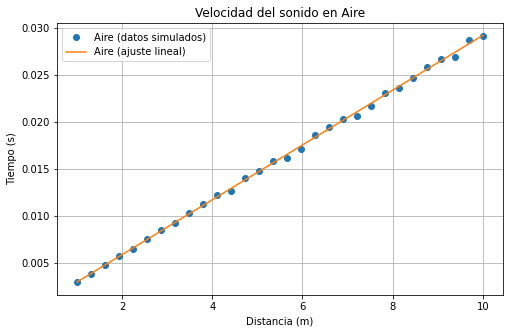


Resultados para Aire:
  Velocidad teórica: 343 m/s
  Velocidad promedio simulada: 341.82 m/s
  Incertidumbre (95%): ±1.65 m/s
  Ajuste lineal (tiempo vs distancia):
    Pendiente: 0.0029 s/m
    Intercepto: 0.0000 s
    R-cuadrado: 0.9992


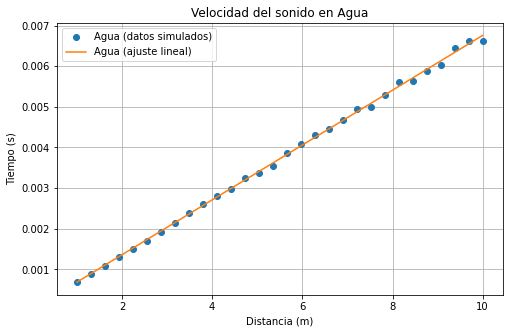


Resultados para Agua:
  Velocidad teórica: 1482 m/s
  Velocidad promedio simulada: 1477.92 m/s
  Incertidumbre (95%): ±6.57 m/s
  Ajuste lineal (tiempo vs distancia):
    Pendiente: 0.0007 s/m
    Intercepto: 0.0000 s
    R-cuadrado: 0.9990


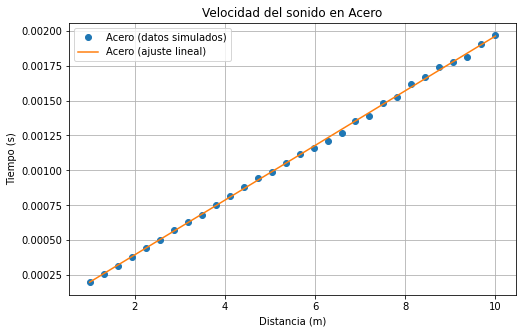


Resultados para Acero:
  Velocidad teórica: 5100 m/s
  Velocidad promedio simulada: 5085.74 m/s
  Incertidumbre (95%): ±21.02 m/s
  Ajuste lineal (tiempo vs distancia):
    Pendiente: 0.0002 s/m
    Intercepto: 0.0000 s
    R-cuadrado: 0.9994


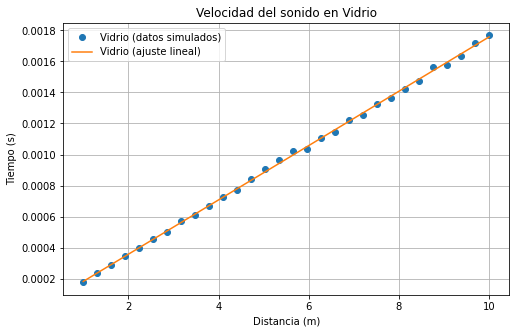


Resultados para Vidrio:
  Velocidad teórica: 5640 m/s
  Velocidad promedio simulada: 5659.67 m/s
  Incertidumbre (95%): ±24.03 m/s
  Ajuste lineal (tiempo vs distancia):
    Pendiente: 0.0002 s/m
    Intercepto: 0.0000 s
    R-cuadrado: 0.9994


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Constantes teóricas para la velocidad del sonido en distintos medios (m/s)
constantes = {
    "Aire": 343,    # Velocidad del sonido en el aire
    "Agua": 1482,   # Velocidad del sonido en el agua
    "Acero": 5100,  # Velocidad del sonido en el acero
    "Vidrio": 5640  # Velocidad del sonido en el vidrio
}

# Función para simular mediciones con incertidumbre
def simular_mediciones(velocidad_teorica, num_mediciones, incertidumbre_relativa):
    mediciones = velocidad_teorica * (1 + np.random.uniform(-incertidumbre_relativa, incertidumbre_relativa, num_mediciones))
    return mediciones

# Generar datos simulados
num_mediciones = 30
incertidumbre_relativa = 0.02  # 2% de incertidumbre relativa

data = {}
for medio, velocidad in constantes.items():
    data[medio] = simular_mediciones(velocidad, num_mediciones, incertidumbre_relativa)

# Análisis de datos
for medio, mediciones in data.items():
    promedio = np.mean(mediciones)
    desviacion_estandar = np.std(mediciones)
    incertidumbre = desviacion_estandar / np.sqrt(num_mediciones)

    # Ajuste lineal: en este caso, simulamos como si tuviéramos "distancia" y "tiempo"
    distancias = np.linspace(1, 10, num_mediciones)  # Simulamos distancias de 1 a 10 m
    tiempos = distancias / mediciones  # Tiempo = distancia / velocidad
    slope, intercept, r_value, p_value, std_err = linregress(distancias, tiempos)

    # Graficar mediciones
    plt.figure(figsize=(8, 5))
    plt.plot(distancias, tiempos, 'o', label=f"{medio} (datos simulados)")
    plt.plot(distancias, slope * distancias + intercept, '-', label=f"{medio} (ajuste lineal)")
    plt.xlabel("Distancia (m)")
    plt.ylabel("Tiempo (s)")
    plt.title(f"Velocidad del sonido en {medio}")
    plt.legend()
    plt.grid()
    plt.show()

    # Resultados
    print(f"\nResultados para {medio}:")
    print(f"  Velocidad teórica: {constantes[medio]} m/s")
    print(f"  Velocidad promedio simulada: {promedio:.2f} m/s")
    print(f"  Incertidumbre (95%): ±{2 * incertidumbre:.2f} m/s")
    print(f"  Ajuste lineal (tiempo vs distancia):")
    print(f"    Pendiente: {slope:.4f} s/m")
    print(f"    Intercepto: {intercept:.4f} s")
    print(f"    R-cuadrado: {r_value**2:.4f}")
